# Scenario B2 Forecasts: Multiple Suppliers with REC — Explicit Forecast Scheduling (Net Generators)

**Description:** Multi-supplier REC scenario identical to B2 but where DA and ID market scheduling
uses dedicated per-participant forecast CSV files rather than falling back to actuals. Prosumers are
**net generators** (RES only, no local load). Imbalances reflect the error between the ID forecast
position and the REC-corrected actual position.

**Participant–supplier assignment:**
| Supplier / BG | Participants |
|---|---|
| SUP_A / BG_A | consumer_001 (Local Authority) · consumer_002 (Apartment) · consumer_003 (Apartment) · consumer_004 (Hot Water Boiler) · consumer_005 (Bank) · consumer_006 (Household) |
| SUP_B / BG_B | prosumer_001 (Fire Station) · prosumer_002 (Household) · prosumer_003 (Household) |

**Configuration:**
| Parameter | Value |
|---|---|
| Suppliers | 2 — SUP_A, SUP_B |
| Balancing Groups | 2 — BG_A (consumers only), BG_B (prosumers only) |
| RECs | 1 — REC_01 (all 9 members, proportional sharing) |
| Prosumer type | **Net generator** (RES only, no local load) |
| Forecast mode | Explicit DA + ID forecast CSVs per participant |
| REC incentives | Shared energy: 0.01 €/kWh · Self-consumption: 0.015 €/kWh |
| Battery | None |

**Comparison pairs (net-generator track):**
- B2-forecasts vs B2 → impact of forecast error on imbalance costs (perfect info vs forecasts)
- B2-forecasts vs A2 → multi-supplier + forecasts vs single-supplier with actuals
- B2-forecasts vs B1 → REC value under explicit forecast scheduling

## 1. Import Dependencies
Import the EnergyMarketOperations class which handles the complete market simulation pipeline.

In [ ]:
from energy_market_operations import EnergyMarketOperations

## 2. Initialize Pipeline
Load the scenario configuration from JSON and create the pipeline instance. The config specifies participants, suppliers, market prices, and network topology.

In [ ]:
CONFIG_FILE = "B2_multiple_suppliers_with_rec_Forecasting (net generators).json"
pipe = EnergyMarketOperations(CONFIG_FILE, scenario_name="B2_forecasts")

## 3. Run Full Pipeline
Execute the complete market simulation:
1. **Day-Ahead Market** - Schedule energy positions based on DA forecasts (per BG)
2. **Intra-Day Market** - Adjust positions with updated ID forecasts (per BG)
3. **REC Settlement** - Proportional energy sharing within community
4. **Balancing Market** - Settle imbalances at dual pricing (per BG)
5. **Supplier Billing** - Calculate final costs per participant

In [ ]:
pipe.run_all()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Running full pipeline for: B2_forecasts
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  SCENARIO: B2_forecasts
  System  : Multiple Suppliers with REC - REC-Aware Forecast - Scenario B2-Forecasts
  Period  : 2016-01-01 → 2016-12-31
  Suppliers    : 2
  Prosumers    : 3
  Consumers    : 6
  RECs         : 1  →  has_rec = True
  Battery      : False
✓ Prices loaded: (35136, 5)  from prices.csv
✓ Load actual : (35136, 153)
✓ RES actual  : (35136, 27)
✓ Load forecast DA: (35136, 6)
✓ RES  forecast DA: (35136, 3)
✓ Load forecast ID: (35136, 6)
✓ RES  forecast ID: (35136, 3)
  ✓ DA forecasts corrected for anticipated REC sharing
✓ DA market: (70272, 8)
  ✓ ID forecasts corrected for anticipated REC sharing
✓ ID market : (70272, 19)
⚠ Battery optimization: skipped (no battery in config)
✓ REC settlement: 1 REC(s) processed
✓ Balancing market: (70272, 31)
✓ Customer billing: 

## 4. Financial Summary
Display aggregated financial results including total revenues, costs, and profit/loss for each supplier.

In [ ]:
pipe.summary()


  ANNUAL FINANCIAL SUMMARY – B2_FORECASTS

  SUP_A (Supplier A):

    REVENUES:
      Energy Market Sales : €        0.00
      Balancing Rewards   : €       41.48
      Retail Sales        : €   21,123.93
      ────────────────────────────────────────────
      Total Revenue       : €   21,165.40

    COSTS:
      Market Purchases    : €    3,463.56
      Balancing Penalties  : €       43.36
      Retail Purchases     : €        0.00
      ────────────────────────────────────────────
      Total Costs          : €    3,506.91

    PROFIT/LOSS:
      Annual Total         : €   17,658.49
      Monthly Average      : €    1,471.54

    IMBALANCE:
      System Position      : LONG
      Total Imbalance      :        -0.04 MWh
      BG Actual Position   :       105.09 MWh
      BG Forecast Position :       105.13 MWh

    REC SHARING:
      Shared Energy        :        43.24 MWh

  SUP_B (Supplier B):

    REVENUES:
      Energy Market Sales : €      283.12
      Balancing Rewards   : € 

## 5. Financial Visualization
Plot breakdown of revenues and costs by category (DA purchases, ID adjustments, balancing costs, customer sales).

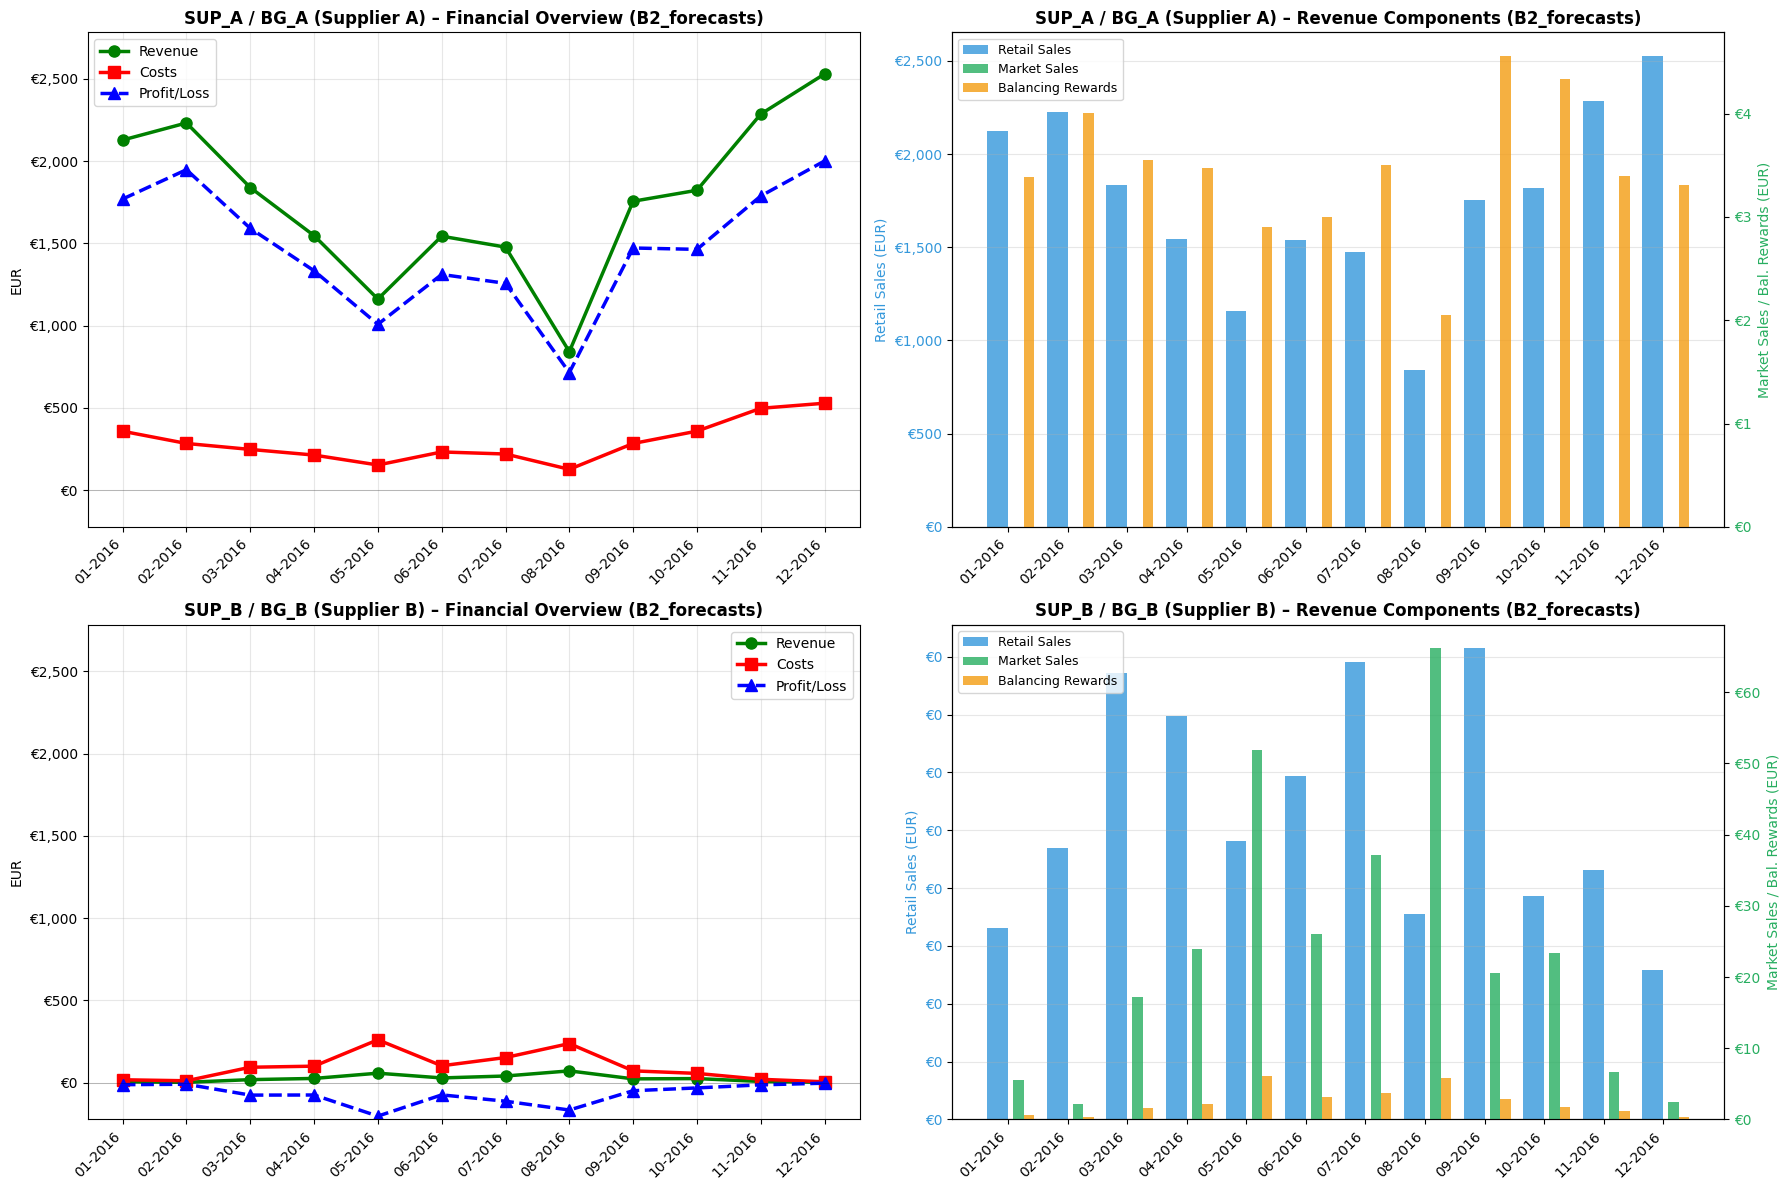

In [ ]:
pipe.plot_financials()

## 6. Imbalance Analysis
Visualize system imbalances over time showing the difference between scheduled positions and actual metered values.

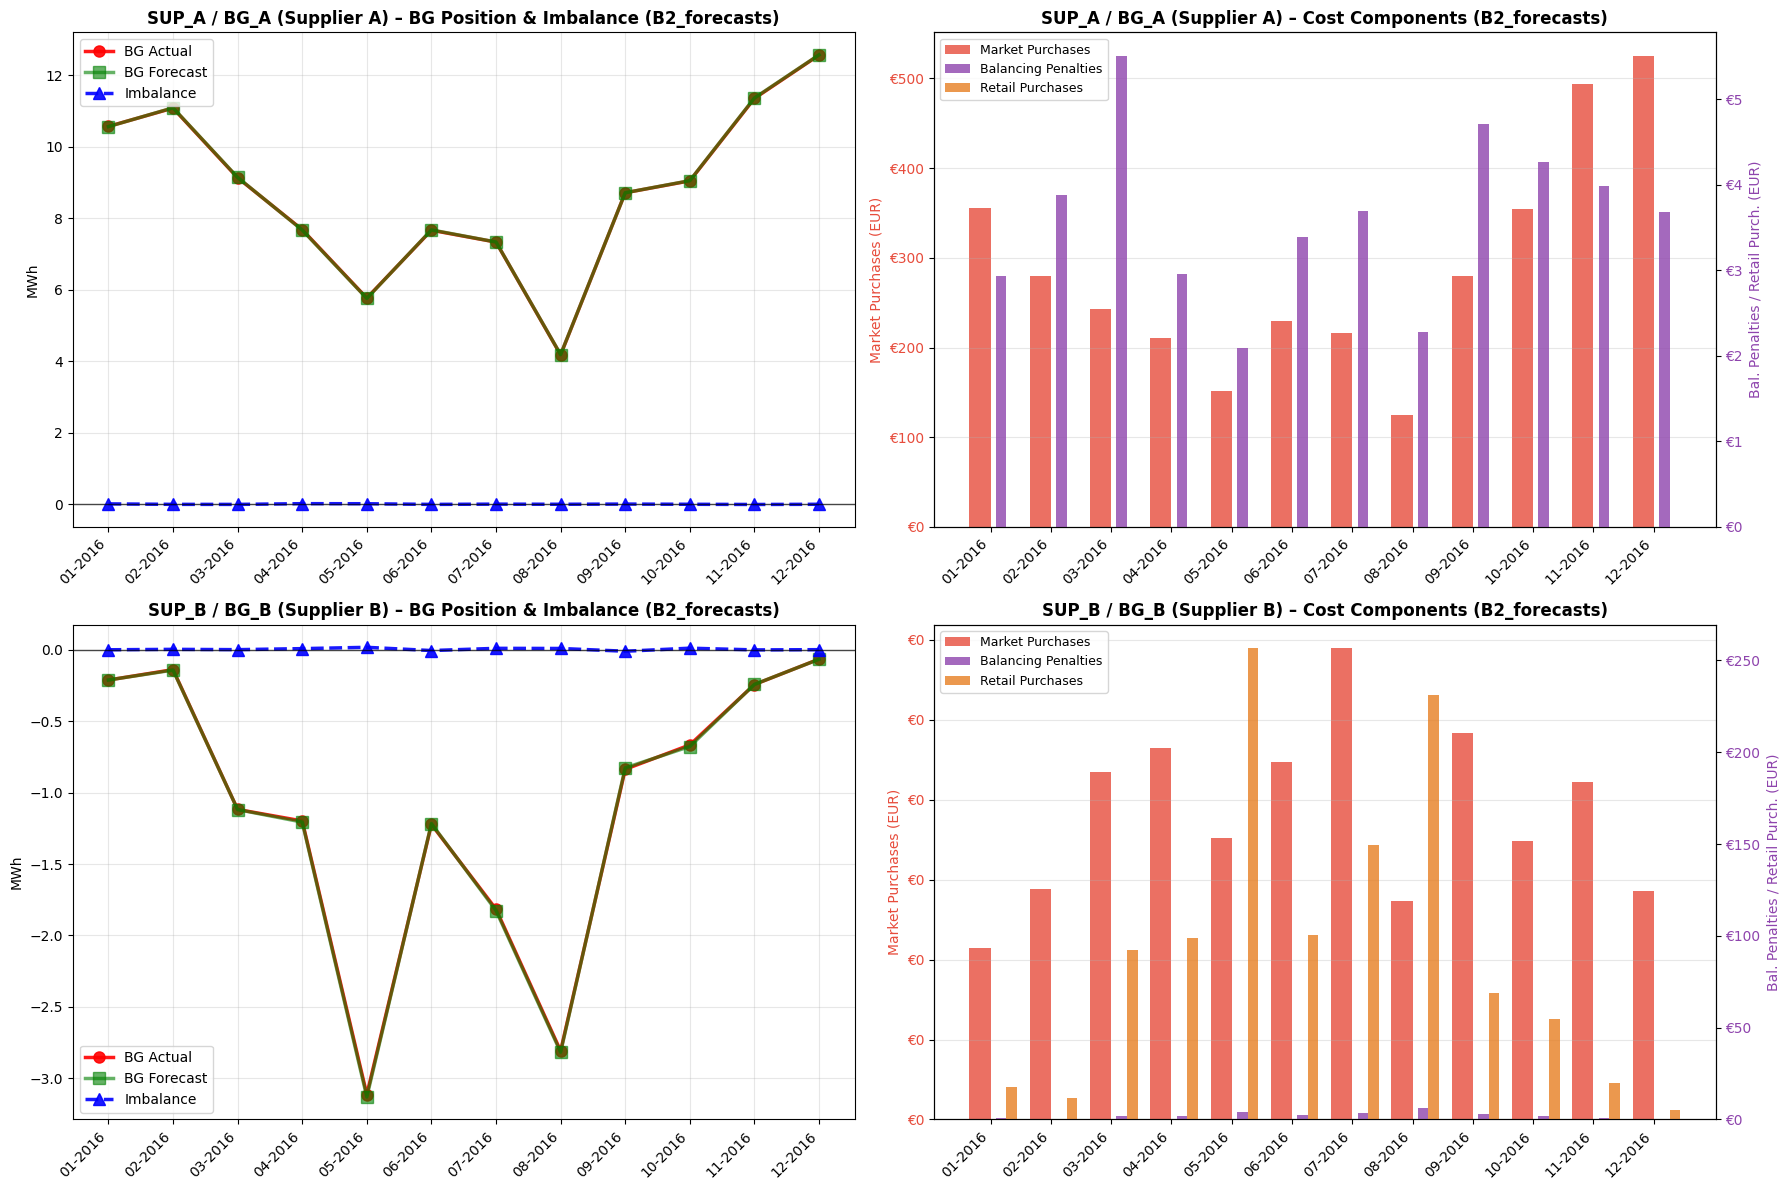

In [ ]:
pipe.plot_imbalances()

## 7. Monthly Analysis
Monthly aggregated results including energy volumes, market costs, and REC sharing.

In [ ]:
pipe.es_monthly_analysis_df

,datetime,supplier_id,balancing_group_id,da_net_load_forecast_mwh,da_net_gen_forecast_mwh,da_purchase_commitment_eur,da_sale_commitment_eur,id_net_load_adjustment_mwh,id_net_gen_adjustment_mwh,id_price_eur_per_mwh,...,internal_shared_energy_mwh,revenue_energy_market_sales_eur,revenue_balancing_rewards_eur,revenue_retail_sales_eur,total_revenue_eur,cost_energy_market_purchases_eur,cost_balancing_penalties_eur,cost_retail_purchases_eur,total_costs_eur,profit_loss_eur
0,01-2016,SUP_A,BG_A,1.174029e+01,1.561929e-18,3.953812e+02,4.683391e-17,-1.175045e+00,-6.030875e-19,29.579375,...,1.415370,2.693805e-17,3.386835,2.124611e+03,2127.997422,3.555328e+02,2.927602,0.000000,358.460372,1769.537050
1,01-2016,SUP_B,BG_B,7.982438e-18,1.807906e-01,2.693360e-16,4.664840e+00,-1.788934e-18,3.093242e-02,29.579375,...,1.415370,5.529485e+00,0.623072,1.658951e-15,6.152556,2.140717e-16,0.537562,17.445818,17.983379,-11.830823
2,02-2016,SUP_A,BG_A,1.243763e+01,1.165517e-18,3.144802e+02,1.805779e-17,-1.345223e+00,-5.353248e-19,22.463459,...,2.583306,1.019679e-17,4.007558,2.227910e+03,2231.917239,2.802285e+02,3.881518,0.000000,284.110067,1947.807172
3,02-2016,SUP_B,BG_B,1.151965e-17,1.211621e-01,2.929245e-16,1.882415e+00,-6.098637e-19,2.109594e-02,22.463459,...,2.583306,2.230811e+00,0.363809,2.348138e-15,2.594621,2.885191e-16,0.388546,11.479986,11.868531,-9.273911
4,03-2016,SUP_A,BG_A,1.035273e+01,6.430674e-18,2.747252e+02,1.421020e-16,-1.208871e+00,-1.067262e-18,24.094009,...,4.026927,1.208033e-16,3.555010,1.835982e+03,1839.536929,2.425087e+02,5.505053,0.000000,248.013777,1591.523152
5,03-2016,SUP_B,BG_B,2.051853e-17,1.026866e+00,5.540237e-16,1.516811e+01,-4.485886e-18,9.198256e-02,24.094009,...,4.026927,1.718104e+01,1.628373,3.859990e-15,18.809413,4.351132e-16,1.932045,92.125373,94.057418,-75.248005
6,04-2016,SUP_A,BG_A,8.797402e+00,7.426785e-18,2.413985e+02,1.771415e-16,-1.127719e+00,3.157739e-18,25.257687,...,5.212260,2.725768e-16,3.471883,1.543790e+03,1547.261806,2.106699e+02,2.955769,0.000000,213.625697,1333.636109
7,04-2016,SUP_B,BG_B,1.692711e-17,1.032603e+00,4.015865e-16,1.968303e+01,1.111307e-18,1.739158e-01,25.257687,...,5.212260,2.390154e+01,2.150941,3.484070e-15,26.052479,4.653865e-16,1.886633,98.756626,100.643259,-74.590780
8,05-2016,SUP_A,BG_A,6.573481e+00,1.792999e-17,1.732324e+02,4.040088e-16,-8.175455e-01,-8.504211e-19,22.993579,...,5.025997,4.066600e-16,2.903663,1.158746e+03,1161.649757,1.513169e+02,2.096854,0.000000,153.413779,1008.235978
9,05-2016,SUP_B,BG_B,1.179070e-17,2.838498e+00,3.118529e-16,4.497276e+01,8.402567e-19,2.923928e-01,22.993579,...,5.025997,5.182588e+01,6.132678,2.408067e-15,57.958557,3.526533e-16,4.299420,256.569430,260.868850,-202.910293
